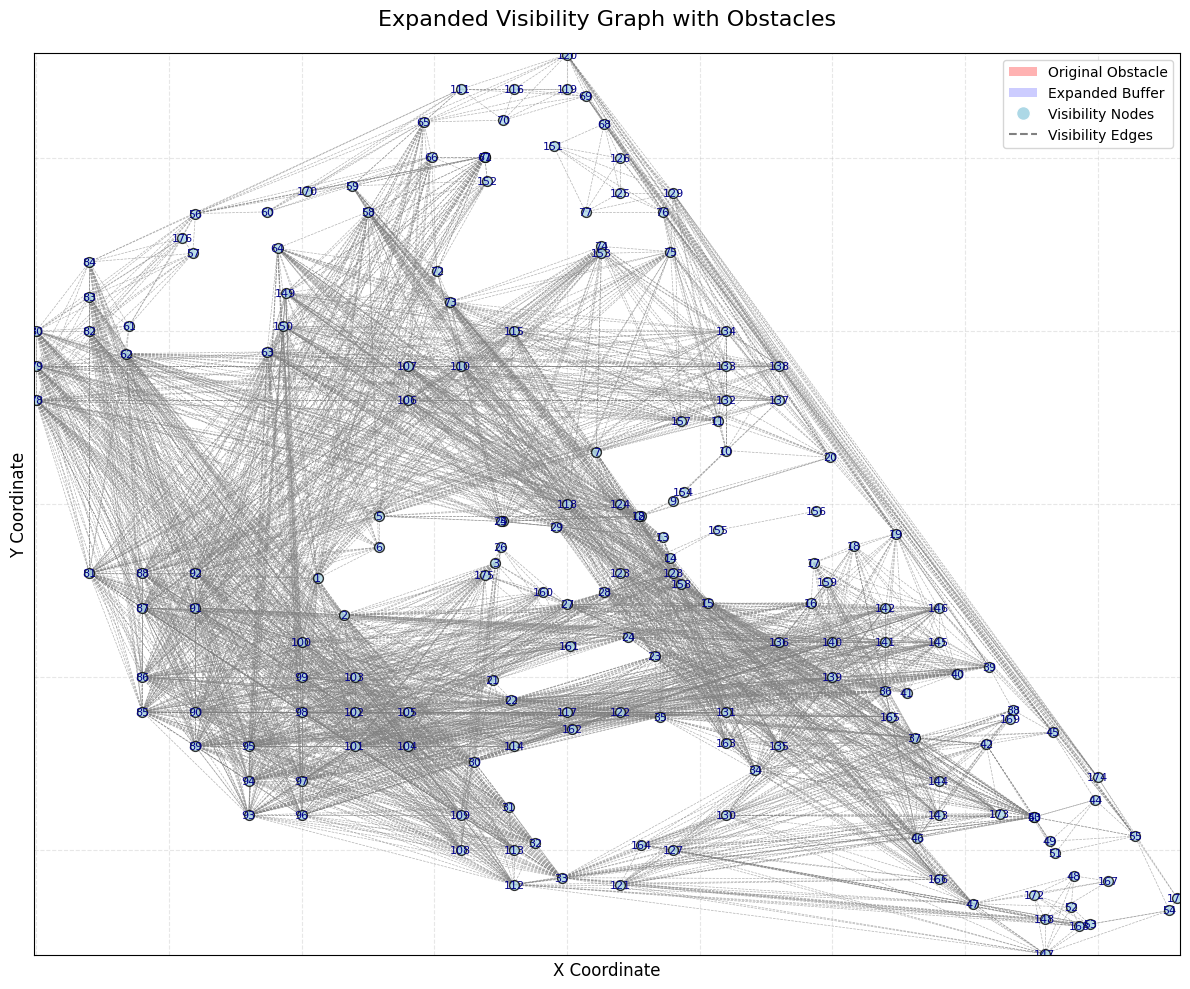

In [10]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import PatchCollection
import numpy as np

# 1. 读取JSON文件
with open('expanded_visibility_graph_renumbered.json', 'r') as f:
    data = json.load(f)

# 2. 创建图形
G = nx.Graph()

# 3. 添加节点
for node in data['nodes']:
    node_id = node['id']
    pos = node['bar']
    G.add_node(node_id, pos=pos)

# 4. 添加边
for link in data['links']:
    source = link['source']
    target = link['target']
    weight = link['foo']
    G.add_edge(source, target, weight=weight)

# 5. 获取节点位置
pos = nx.get_node_attributes(G, 'pos')

# 6. 创建图形
plt.figure(figsize=(12, 10))



# 9. 绘制网络
nx.draw_networkx_nodes(G, pos, node_size=50, node_color='lightblue', 
                      alpha=0.8, edgecolors='black', linewidths=1)

nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.6, 
                      width=0.5, style='dashed')  # 线宽调细

nx.draw_networkx_labels(G, pos, font_size=8, font_color='darkblue')

# 10. 添加图例和标题
plt.title('Expanded Visibility Graph with Obstacles', fontsize=16, pad=20)
plt.xlabel('X Coordinate', fontsize=12)
plt.ylabel('Y Coordinate', fontsize=12)

# 创建自定义图例
from matplotlib.lines import Line2D
legend_elements = [
    patches.Patch(facecolor='red', alpha=0.3, label='Original Obstacle'),
    patches.Patch(facecolor='blue', alpha=0.2, label='Expanded Buffer'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', 
           markersize=10, label='Visibility Nodes'),
    Line2D([0], [0], color='gray', linestyle='dashed', label='Visibility Edges')
]

plt.legend(handles=legend_elements, loc='upper right')

# 11. 设置坐标轴范围
all_x = [pos[0] for pos in pos.values()]
all_y = [pos[1] for pos in pos.values()]
plt.xlim(min(all_x) - 1, max(all_x) + 1)
plt.ylim(min(all_y) - 1, max(all_y) + 1)

# 12. 添加网格
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
# 导出为矢量图（如SVG或PDF）
plt.savefig("expanded_visibility_graph.svg", format="svg", bbox_inches='tight')
plt.savefig("expanded_visibility_graph.pdf", format="pdf", bbox_inches='tight')
plt.show()

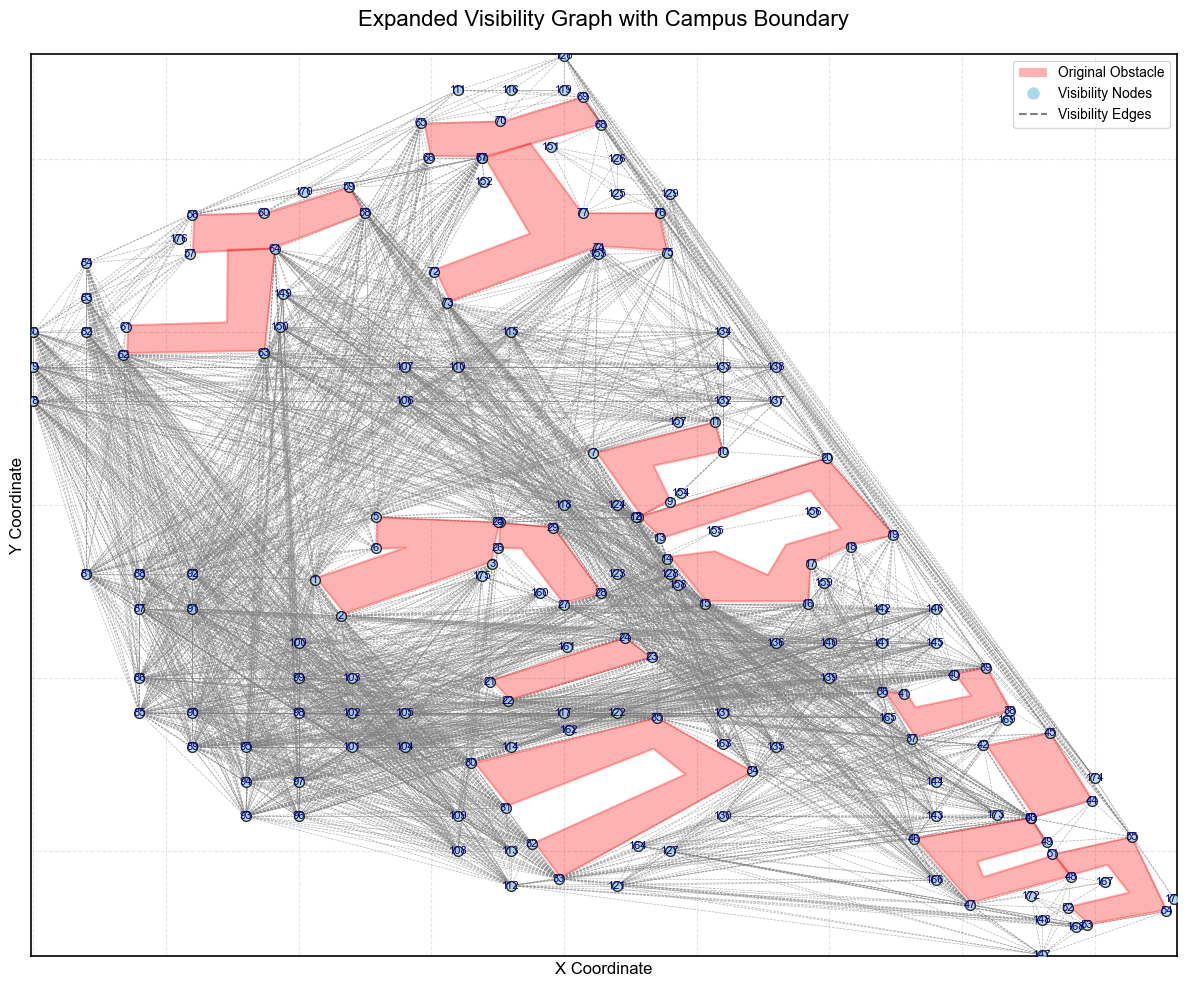

In [6]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon
import numpy as np
from pathlib import Path

# 1. 读取JSON文件
with open('expanded_visibility_graph_renumbered.json', 'r') as f:
    data = json.load(f)

# 2. 创建图形
G = nx.Graph()

# 3. 添加节点
for node in data['nodes']:
    node_id = node['id']
    pos = node['bar']
    G.add_node(node_id, pos=pos)

# 4. 添加边
for link in data['links']:
    source = link['source']
    target = link['target']
    weight = link['foo']
    G.add_edge(source, target, weight=weight)

# 5. 获取节点位置
pos = nx.get_node_attributes(G, 'pos')

# 6. 创建图形
fig, ax = plt.subplots(figsize=(12, 10))

# 7. 【新增】加载并绘制校园边界（最底层）
boundary_path = Path('..') / 'data_empirical' / 'boan.geojson'
if boundary_path.exists():
    with open(boundary_path, 'r', encoding='utf-8') as f:
        boundary_data = json.load(f)
    
    for feature in boundary_data.get('features', []):
        geometry = feature.get('geometry', {})
        if geometry.get('type') == 'Polygon':
            coords = geometry.get('coordinates', [])
            if coords:
                boundary_coords = np.array(coords[0])  # 外环
                # 绘制边界填充（浅灰色底图）
                boundary_poly = Polygon(boundary_coords, closed=True,
                                       facecolor='lightgray',  # 浅灰色填充
                                       alpha=0.15,  # 很淡的透明度
                                       edgecolor='none',  # 先不画边界线
                                       zorder=0)  # 最底层
                ax.add_patch(boundary_poly)
                
                # 绘制边界线（黑色，在网络上层）
                ax.plot(boundary_coords[:, 0], boundary_coords[:, 1], 
                       color='black', linewidth=2.0, zorder=3, label='Campus Boundary')

# 8. 【新增】加载并绘制障碍物
obstacles_patches = []
expanded_patches = []

# 尝试加载障碍物数据
buildings_geojson_path = Path('..') / 'output' / 'transformed_buildings.geojson'
if buildings_geojson_path.exists():
    with open(buildings_geojson_path, 'r', encoding='utf-8') as f:
        buildings_data = json.load(f)
    
    for feature in buildings_data.get('features', []):
        geometry = feature.get('geometry', {})
        if geometry.get('type') == 'Polygon':
            coords = geometry.get('coordinates', [])
            if coords:
                # 原始障碍物（红色）
                poly_coords = np.array(coords[0])  # 外环
                poly = Polygon(poly_coords, closed=True, 
                              facecolor='red', alpha=0.3, 
                              edgecolor='red', linewidth=1.5,
                              zorder=1)  # 在边界之上
                obstacles_patches.append(poly)

# 绘制障碍物
if obstacles_patches:
    obstacles_collection = PatchCollection(obstacles_patches, match_original=True, zorder=1)
    ax.add_collection(obstacles_collection)

if expanded_patches:
    expanded_collection = PatchCollection(expanded_patches, match_original=True, zorder=1)
    ax.add_collection(expanded_collection)

# 9. 绘制网络（最上层）
# 注意：NetworkX 的绘图函数不支持 zorder，需要绘制后手动设置
nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray', alpha=0.6, 
                      width=0.5, style='dashed')

nx.draw_networkx_nodes(G, pos, ax=ax, node_size=50, node_color='lightblue', 
                      alpha=0.8, edgecolors='black', linewidths=1)

nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color='darkblue')

# 绘制后设置 zorder（通过访问 ax 的子元素）
for collection in ax.collections:
    if hasattr(collection, 'set_zorder'):
        # 判断是边还是节点
        try:
            facecolors = collection.get_facecolor()
            if facecolors.size > 0 and np.any(facecolors[:, 3] > 0):  # 节点（有填充色）
                collection.set_zorder(4)
            else:  # 边（无填充色或透明）
                collection.set_zorder(2)
        except:
            # 如果判断失败，默认边在节点下方
            if len(ax.collections) > 1:
                # 通常第一个是边，第二个是节点
                idx = list(ax.collections).index(collection)
                collection.set_zorder(2 if idx == 0 else 4)

for text in ax.texts:
    text.set_zorder(5)  # 标签最上层

# 10. 添加图例和标题
ax.set_title('Expanded Visibility Graph with Campus Boundary', fontsize=16, pad=20)
ax.set_xlabel('X Coordinate', fontsize=12)
ax.set_ylabel('Y Coordinate', fontsize=12)

# 创建自定义图例
from matplotlib.lines import Line2D
legend_elements = []
# 添加边界图例
if boundary_path.exists():
    legend_elements.append(
        Line2D([0], [0], color='black', linewidth=2.0, label='Campus Boundary')
    )
if obstacles_patches:
    legend_elements.append(
        patches.Patch(facecolor='red', alpha=0.3, label='Original Obstacle')
    )
if expanded_patches:
    legend_elements.append(
        patches.Patch(facecolor='blue', alpha=0.2, label='Expanded Buffer')
    )
legend_elements.extend([
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', 
           markersize=10, label='Visibility Nodes'),
    Line2D([0], [0], color='gray', linestyle='dashed', label='Visibility Edges')
])

ax.legend(handles=legend_elements, loc='upper right')

# 11. 设置坐标轴范围
all_x = [pos[0] for pos in pos.values()]
all_y = [pos[1] for pos in pos.values()]
ax.set_xlim(min(all_x) - 1, max(all_x) + 1)
ax.set_ylim(min(all_y) - 1, max(all_y) + 1)

# 12. 添加网格
ax.grid(True, alpha=0.3, linestyle='--', zorder=0)

plt.tight_layout()
# 导出为矢量图（如SVG或PDF）
plt.savefig("expanded_visibility_graph.svg", format="svg", bbox_inches='tight')
plt.savefig("expanded_visibility_graph.pdf", format="pdf", bbox_inches='tight')
plt.show()

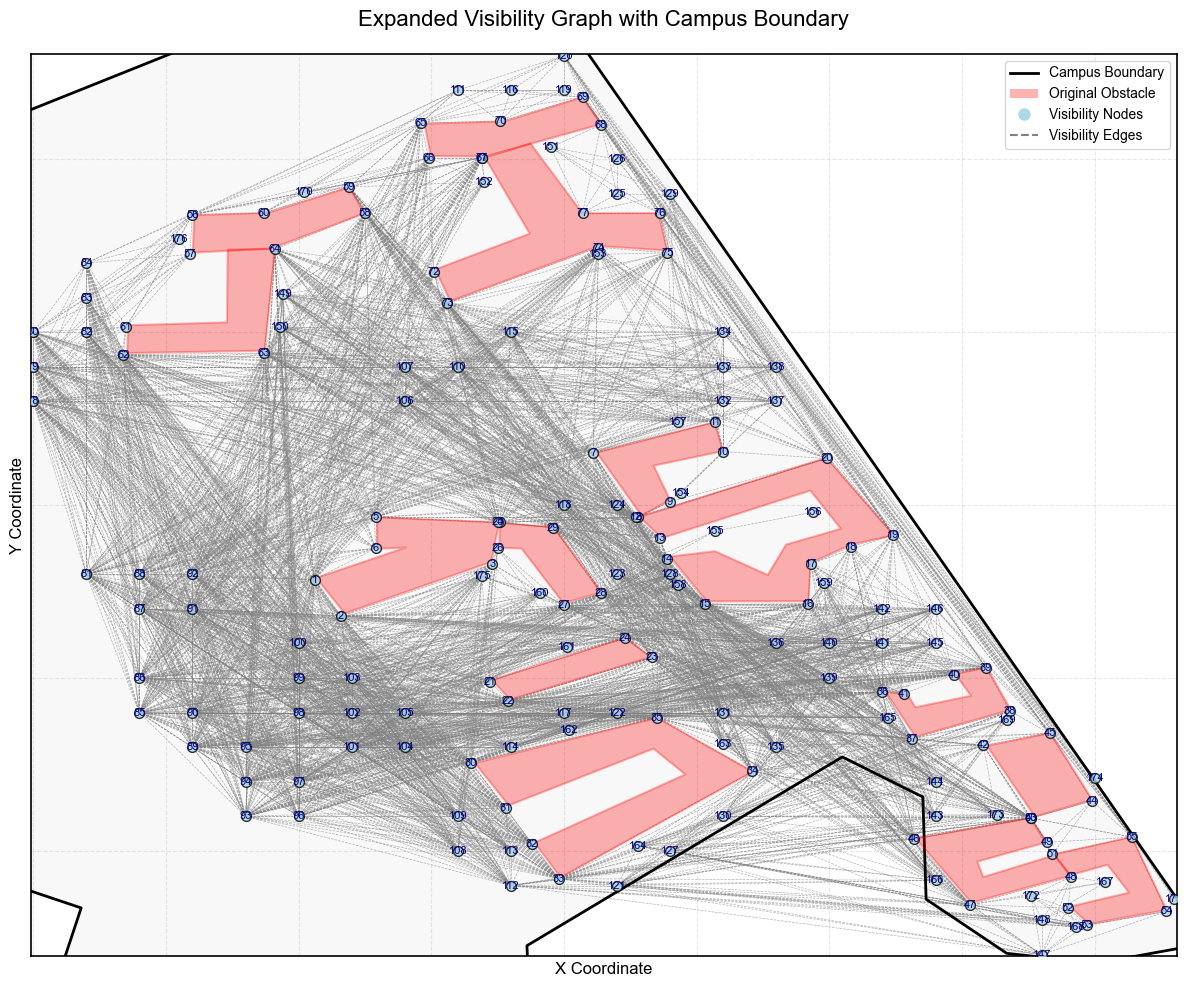

In [7]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon
import numpy as np
import os
from pathlib import Path

# 定义基础路径
base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
boundary_file = os.path.join(base_path, "data_empirical", "boan.geojson")

# 1. 读取JSON文件
json_path = os.path.join(base_path, "data", "env_data", "expanded_visibility_graph_renumbered.json")
with open(json_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# 2. 创建图形
G = nx.Graph()

# 3. 添加节点
for node in data['nodes']:
    node_id = node['id']
    pos = node['bar']
    G.add_node(node_id, pos=pos)

# 4. 添加边
for link in data['links']:
    source = link['source']
    target = link['target']
    weight = link['foo']
    G.add_edge(source, target, weight=weight)

# 5. 获取节点位置
pos = nx.get_node_attributes(G, 'pos')

# 6. 创建图形
fig, ax = plt.subplots(figsize=(12, 10))

# 7. 【新增】加载并绘制校园边界（最底层）
if os.path.exists(boundary_file):
    with open(boundary_file, 'r', encoding='utf-8') as f:
        boundary_data = json.load(f)
    
    for feature in boundary_data.get('features', []):
        geometry = feature.get('geometry', {})
        if geometry.get('type') == 'Polygon':
            coords = geometry.get('coordinates', [])
            if coords:
                boundary_coords = np.array(coords[0])  # 外环
                # 绘制边界填充（浅灰色底图）
                boundary_poly = Polygon(boundary_coords, closed=True,
                                       facecolor='lightgray',  # 浅灰色填充
                                       alpha=0.15,  # 很淡的透明度
                                       edgecolor='none',  # 先不画边界线
                                       zorder=0)  # 最底层
                ax.add_patch(boundary_poly)
                
                # 绘制边界线（黑色，在网络上层）
                ax.plot(boundary_coords[:, 0], boundary_coords[:, 1], 
                       color='black', linewidth=2.0, zorder=3, label='Campus Boundary')

# 8. 【新增】加载并绘制障碍物
obstacles_patches = []
expanded_patches = []

# 尝试加载障碍物数据
buildings_geojson_path = os.path.join(base_path, "data", "output", "transformed_buildings.geojson")
if os.path.exists(buildings_geojson_path):
    with open(buildings_geojson_path, 'r', encoding='utf-8') as f:
        buildings_data = json.load(f)
    
    for feature in buildings_data.get('features', []):
        geometry = feature.get('geometry', {})
        if geometry.get('type') == 'Polygon':
            coords = geometry.get('coordinates', [])
            if coords:
                # 原始障碍物（红色）
                poly_coords = np.array(coords[0])  # 外环
                poly = Polygon(poly_coords, closed=True, 
                              facecolor='red', alpha=0.3, 
                              edgecolor='red', linewidth=1.5,
                              zorder=1)  # 在边界之上
                obstacles_patches.append(poly)

# 绘制障碍物
if obstacles_patches:
    obstacles_collection = PatchCollection(obstacles_patches, match_original=True, zorder=1)
    ax.add_collection(obstacles_collection)

if expanded_patches:
    expanded_collection = PatchCollection(expanded_patches, match_original=True, zorder=1)
    ax.add_collection(expanded_collection)

# 9. 绘制网络（最上层）
# 注意：NetworkX 的绘图函数不支持 zorder，需要绘制后手动设置
nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray', alpha=0.6, 
                      width=0.5, style='dashed')

nx.draw_networkx_nodes(G, pos, ax=ax, node_size=50, node_color='lightblue', 
                      alpha=0.8, edgecolors='black', linewidths=1)

nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color='darkblue')

# 绘制后设置 zorder（通过访问 ax 的子元素）
for collection in ax.collections:
    if hasattr(collection, 'set_zorder'):
        # 判断是边还是节点
        try:
            facecolors = collection.get_facecolor()
            if facecolors.size > 0 and np.any(facecolors[:, 3] > 0):  # 节点（有填充色）
                collection.set_zorder(4)
            else:  # 边（无填充色或透明）
                collection.set_zorder(2)
        except:
            # 如果判断失败，默认边在节点下方
            if len(ax.collections) > 1:
                # 通常第一个是边，第二个是节点
                idx = list(ax.collections).index(collection)
                collection.set_zorder(2 if idx == 0 else 4)

for text in ax.texts:
    text.set_zorder(5)  # 标签最上层

# 10. 添加图例和标题
ax.set_title('Expanded Visibility Graph with Campus Boundary', fontsize=16, pad=20)
ax.set_xlabel('X Coordinate', fontsize=12)
ax.set_ylabel('Y Coordinate', fontsize=12)

# 创建自定义图例
from matplotlib.lines import Line2D
legend_elements = []
# 添加边界图例
if os.path.exists(boundary_file):
    legend_elements.append(
        Line2D([0], [0], color='black', linewidth=2.0, label='Campus Boundary')
    )
if obstacles_patches:
    legend_elements.append(
        patches.Patch(facecolor='red', alpha=0.3, label='Original Obstacle')
    )
if expanded_patches:
    legend_elements.append(
        patches.Patch(facecolor='blue', alpha=0.2, label='Expanded Buffer')
    )
legend_elements.extend([
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue', 
           markersize=10, label='Visibility Nodes'),
    Line2D([0], [0], color='gray', linestyle='dashed', label='Visibility Edges')
])

ax.legend(handles=legend_elements, loc='upper right')

# 11. 设置坐标轴范围
all_x = [pos[0] for pos in pos.values()]
all_y = [pos[1] for pos in pos.values()]
ax.set_xlim(min(all_x) - 1, max(all_x) + 1)
ax.set_ylim(min(all_y) - 1, max(all_y) + 1)

# 12. 添加网格
ax.grid(True, alpha=0.3, linestyle='--', zorder=0)

plt.tight_layout()
# 导出为矢量图（如SVG或PDF）
output_dir = os.path.join(base_path, "data", "env_data")
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "expanded_visibility_graph.svg"), format="svg", bbox_inches='tight')
plt.savefig(os.path.join(output_dir, "expanded_visibility_graph.pdf"), format="pdf", bbox_inches='tight')
plt.show()

In [11]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon
import numpy as np
import os

# 设置 matplotlib 为学术发表模式
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
})

def plot_publication_visibility_graph(json_path, boundary_path, buildings_path=None,
                                      output_path=None, dpi=300, save_format='pdf',
                                      show_node_labels=False, node_size=40):
    """
    学术发表级别的可视图网络图
    
    参数:
    - json_path: 网络图 JSON 文件路径
    - boundary_path: 校园边界 GeoJSON 文件路径
    - buildings_path: 建筑物障碍物 GeoJSON 文件路径（可选）
    - output_path: 保存路径（如果为 None 则只显示）
    - dpi: 分辨率（期刊通常要求 300-600 DPI）
    - save_format: 保存格式 ('pdf', 'png', 'eps', 'tiff')
    - show_node_labels: 是否显示节点标签（默认 False，避免过于密集）
    - node_size: 节点大小
    """
    if not os.path.exists(json_path):
        print(f"文件不存在: {json_path}")
        return

    # 1. 读取网络图数据
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # 2. 创建 NetworkX 图
    G = nx.Graph()
    for node in data['nodes']:
        node_id = node['id']
        pos = node['bar']
        G.add_node(node_id, pos=pos)

    for link in data['links']:
        source = link['source']
        target = link['target']
        weight = link.get('foo', 1.0)
        G.add_edge(source, target, weight=weight)

    pos = nx.get_node_attributes(G, 'pos')

    # 3. 创建图形（学术发表通常使用单栏或双栏宽度）
    fig_width = 7.0  # 适合双栏或大图
    fig_height = 6.5
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi, facecolor='white')

    # 4. 绘制校园边界（已移除，用于对比效果）
    # if os.path.exists(boundary_path):
    #     with open(boundary_path, 'r', encoding='utf-8') as f:
    #         boundary_data = json.load(f)
    #     
    #     for feature in boundary_data.get('features', []):
    #         geometry = feature.get('geometry', {})
    #         if geometry.get('type') == 'Polygon':
    #             coords = geometry.get('coordinates', [])
    #             if coords:
    #                 boundary_coords = np.array(coords[0])
    #                 # 边界填充（浅灰色底图）
    #                 boundary_poly = Polygon(boundary_coords, closed=True,
    #                                        facecolor='#f5f5f5',  # 更淡的灰色
    #                                        alpha=0.3,
    #                                        edgecolor='none',
    #                                        zorder=0)
    #                 ax.add_patch(boundary_poly)
    #                 
    #                 # 边界线（黑色，更细更专业）
    #                 ax.plot(boundary_coords[:, 0], boundary_coords[:, 1], 
    #                        color='black', linewidth=1.5, zorder=3)

    # 5. 绘制建筑物障碍物（如果有）
    obstacles_patches = []
    if buildings_path and os.path.exists(buildings_path):
        with open(buildings_path, 'r', encoding='utf-8') as f:
            buildings_data = json.load(f)
        
        for feature in buildings_data.get('features', []):
            geometry = feature.get('geometry', {})
            if geometry.get('type') == 'Polygon':
                coords = geometry.get('coordinates', [])
                if coords:
                    poly_coords = np.array(coords[0])
                    # 使用更学术的颜色（深灰色而非红色）
                    poly = Polygon(poly_coords, closed=True, 
                                  facecolor='#8B8B8B',  # 深灰色
                                  alpha=0.4, 
                                  edgecolor='#666666',  # 更深的灰色边框
                                  linewidth=1.0,
                                  zorder=1)
                    obstacles_patches.append(poly)

    if obstacles_patches:
        obstacles_collection = PatchCollection(obstacles_patches, match_original=True, zorder=1)
        ax.add_collection(obstacles_collection)

    # 6. 绘制网络边（先绘制边，再绘制节点）
    nx.draw_networkx_edges(G, pos, ax=ax, 
                          edge_color='#808080',  # 中灰色
                          alpha=0.5,  # 降低透明度，更专业
                          width=0.4,  # 更细的线
                          style='dashed')

    # 7. 绘制网络节点
    nx.draw_networkx_nodes(G, pos, ax=ax, 
                           node_size=node_size, 
                           node_color='#4A90E2',  # 更专业的蓝色
                           alpha=0.9, 
                           edgecolors='#2C5F8D',  # 深蓝色边框
                           linewidths=0.8)

    # 8. 绘制节点标签（可选，默认关闭避免过于密集）
    if show_node_labels:
        nx.draw_networkx_labels(G, pos, ax=ax, 
                               font_size=7, 
                               font_color='#1a1a1a',  # 深灰色文字
                               font_weight='normal')

    # 9. 设置 zorder（确保正确的图层顺序）
    for collection in ax.collections:
        if hasattr(collection, 'set_zorder'):
            try:
                facecolors = collection.get_facecolor()
                if facecolors.size > 0 and np.any(facecolors[:, 3] > 0):
                    collection.set_zorder(4)  # 节点
                else:
                    collection.set_zorder(2)  # 边
            except:
                if len(ax.collections) > 1:
                    idx = list(ax.collections).index(collection)
                    collection.set_zorder(2 if idx == 0 else 4)

    for text in ax.texts:
        text.set_zorder(5)

    # 10. 设置坐标轴（更专业的标签）
    all_x = [p[0] for p in pos.values()]
    all_y = [p[1] for p in pos.values()]
    ax.set_xlim(min(all_x) - 10, max(all_x) + 10)
    ax.set_ylim(min(all_y) - 10, max(all_y) + 10)
    
    ax.set_xlabel('X Coordinate (m)', fontsize=12, fontweight='normal')
    ax.set_ylabel('Y Coordinate (m)', fontsize=12, fontweight='normal')
    
    # 设置刻度
    ax.tick_params(axis='both', which='major', length=5, width=1.2)
    ax.tick_params(axis='both', which='minor', length=3, width=1.0)

    # 11. 创建图例（更专业的样式）
    from matplotlib.lines import Line2D
    legend_elements = []
    
    # 边界图例已移除
    # if os.path.exists(boundary_path):
    #     legend_elements.append(
    #         Line2D([0], [0], color='black', linewidth=1.5, label='Campus Boundary')
    #     )
    if obstacles_patches:
        legend_elements.append(
            patches.Patch(facecolor='#8B8B8B', alpha=0.4, edgecolor='#666666', 
                         linewidth=1.0, label='Buildings')
        )
    legend_elements.extend([
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#4A90E2', 
               markeredgecolor='#2C5F8D', markersize=8, markeredgewidth=0.8,
               label='Visibility Nodes'),
        Line2D([0], [0], color='#808080', linestyle='dashed', linewidth=0.8, 
               label='Visibility Edges')
    ])

    ax.legend(handles=legend_elements, loc='upper right', 
             frameon=True, fancybox=False, shadow=False,
             framealpha=0.9, edgecolor='gray', facecolor='white')

    # 12. 移除不必要的元素，优化学术风格
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    # 移除网格（学术发表通常不使用网格，或使用非常淡的网格）
    ax.grid(False)  # 或者使用 ax.grid(True, alpha=0.1, linestyle='--', zorder=0)

    # 13. 调整布局
    plt.tight_layout()
    
    # 14. 保存或显示
    if output_path:
        os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else '.', exist_ok=True)
        plt.savefig(output_path, dpi=dpi, format=save_format, 
                   bbox_inches='tight', facecolor='white', edgecolor='none',
                   pad_inches=0.1)
        print(f"已保存到: {output_path} (DPI={dpi}, 格式={save_format})")
    else:
        plt.show()
    
    plt.close()

# --- 执行：生成发表级别的网络图 ---
base_path = r"D:\progamming\python_script\Social-physical-system-shelter"
json_path = os.path.join(base_path, "data", "env_data", "expanded_visibility_graph_renumbered.json")
boundary_file = os.path.join(base_path, "data_empirical", "boan.geojson")
buildings_file = os.path.join(base_path, "data", "output", "transformed_buildings.geojson")

# 生成高分辨率 PDF（适合发表）
output_pdf = os.path.join(base_path, "data", "env_data", "visibility_graph_publication.svg")
plot_publication_visibility_graph(
    json_path, 
    boundary_file, 
    buildings_path=buildings_file,
    output_path=output_pdf,
    dpi=300,
    save_format='svg',
    show_node_labels=False,  # 不显示节点标签，避免过于密集
    node_size=35  # 稍小的节点，更专业
)

# 生成高分辨率 PNG（用于预览）
output_png = os.path.join(base_path, "data", "env_data", "visibility_graph_publication.png")
plot_publication_visibility_graph(
    json_path, 
    boundary_file, 
    buildings_path=buildings_file,
    output_path=output_png,
    dpi=600,
    save_format='png',
    show_node_labels=False,
    node_size=35
)


已保存到: D:\progamming\python_script\Social-physical-system-shelter\data\env_data\visibility_graph_publication.svg (DPI=300, 格式=svg)
已保存到: D:\progamming\python_script\Social-physical-system-shelter\data\env_data\visibility_graph_publication.png (DPI=600, 格式=png)
